# Global Income Inequality Model (SDG 10)

## Problem Statement
High levels of income inequality hinder economic growth, social cohesion, and the achievement of global development targets. Monitoring the relationship between socio-economic indicators—such as education spending and unemployment—is essential for understanding the drivers of inequality. This project focuses on analyzing these indicators to predict the Gini Index, providing a data-driven approach to tracking progress towards **Sustainable Development Goal 10: Reduced Inequalities**.

## Objectives
1. **Trend Analysis**: Examine the 10-year trend (2014-2023) of income inequality (Gini Index) globally, with a specific focus on India, USA, and Brazil.
2. **Correlation Study**: Investigate the relationship between national education spending (% of GDP), unemployment rates (%), and the Gini Index.
3. **Predictive Modeling**: Develop a robust Linear Regression model to estimate the Gini Index based on key socio-economic factors.
4. **Interactive Scenario Simulation**: Provide a user-friendly interface for stakeholders to simulate the potential impact of economic changes on national inequality.

## Project Work Allocation Sheet

### TEAM 1 — PART 1 (Data Preparation Phase)
| SI. No | Task Assigned | Student Name | USN |
| :--- | :--- | :--- | :--- |
| 1 | Data Collection | Adith n k | 1ST22AD001 |
| 2 | Data Cleaning | Mohammed IFTEQHAR | 1VJ22AI019 |
| 3 | Data Preprocessing | Mohamed Ashas | 1VJ22AI017 |
| 4 | Feature Engineering | Abdur Rehman sarim | 1VJ22AI001 |
| 5 | Data Validation | Shaik sahil | 1VJ22AI029 |

### TEAM 2 — PART 2 (Analysis & Implementation)
| SI. No | Task Assigned | Student Name | USN |
| :--- | :--- | :--- | :--- |
| 1 | Data Analysis | Shubha R | 1ST22CS200 |
| 2 | Technical Analysis Support | Ritesh | 1ME22CS121 |
| 3 | Repository Maintenance | Guruprasad Pujari | 2BL23CI402 |
| 4 | Results Output Generation | Sankirana | 2BL22CI042 |
| 5 | Documentation & Reporting | Koushalya siddappa Gujjatti | 1B022AI012 |

---

This notebook represents the **Modeling and Prediction** phase of our Global Income Inequality project. Following our team's **Waterfall Model**, this work builds upon the successful completion of the previous stages outlined in the allocation sheet above.

---

## 1. Environment Setup and Data Loading
We start by importing the necessary libraries and loading the preprocessed dataset. 

**Team Contribution:** Building on the software environment established during Phase 1.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error
import joblib
import ipywidgets as widgets
from ipywidgets import interact
import os

# Premium Visualization Style
plt.style.use('ggplot')
sns.set_palette("viridis")

In [2]:
# DATA PIPELINE: Loading and merging raw data (Phase 1 & 2 logic)
data_dir = r"C:\global-income-inequality-project\data\raw"
gini_path = os.path.join(data_dir, "gini_index.xls")
edu_path = os.path.join(data_dir, "eduacation spending.xls")
unemp_path = os.path.join(data_dir, "unemployment_data.xls")

df_gini = pd.read_excel(gini_path, skiprows=3)
df_edu = pd.read_excel(edu_path, skiprows=3)
df_unemp = pd.read_excel(unemp_path, skiprows=3)

years = [str(y) for y in range(2014, 2024)]

def melt_df(df, val_name):
    return df.melt(id_vars=['Country Name', 'Country Code'], 
                   value_vars=years, 
                   var_name='Year', value_name=val_name)

df_gini_long = melt_df(df_gini, 'Gini_Index')
df_edu_long = melt_df(df_edu, 'Education_Spending_%GDP')
df_unemp_long = melt_df(df_unemp, 'Unemployment_%')

merged_df = df_gini_long.merge(df_edu_long, on=['Country Name', 'Country Code', 'Year'])
merged_df = merged_df.merge(df_unemp_long, on=['Country Name', 'Country Code', 'Year'])

# TRANSFORMATION (Phase 3 credit & Technical Support)
# Focusing on target countries: India, United States, and Brazil
target_df = merged_df[merged_df['Country Name'].isin(['India', 'United States', 'Brazil'])].dropna()
print(f"Dataset size for modeling (Target Countries): {len(target_df)}")
target_df.head()

Dataset size for modeling (Target Countries): 17


,Country Name,Country Code,Year,Gini_Index,Education_Spending_%GDP,Unemployment_%
29,Brazil,BRA,2014,52.0,5.94848,6.755
295,Brazil,BRA,2015,51.9,6.24106,8.538
517,United States,USA,2015,41.5,4.93063,5.280
561,Brazil,BRA,2016,53.4,6.31404,11.580
783,United States,USA,2016,41.3,4.78328,4.869


## 2. Linear Regression Modeling
**Current Phase: Modeling & Results Output Generation**

We use Linear Regression to model the relationship between Education Spending, Unemployment, and the Gini Index. This model helps us understand if these socio-economic indicators are significant predictors of income inequality.

In [3]:
# Features and Target
X = target_df[['Education_Spending_%GDP', 'Unemployment_%']]
y = target_df['Gini_Index']

# Split the data
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Initialize and train the model
model = LinearRegression()
model.fit(X_train, y_train)

# Predictions
y_pred = model.predict(X_test)

# PERSISTENCE: Dumping the model (Phase 3 Repository Maintenance support)
joblib.dump(model, 'sdg10_gini_model.joblib')
print("Model trained and saved as 'sdg10_gini_model.joblib'")

print(f"\nModel Coefficients: {dict(zip(X.columns, model.coef_))}")
print(f"Model Intercept: {model.intercept_:.4f}")

Model trained and saved as 'sdg10_gini_model.joblib'

Model Coefficients: {'Education_Spending_%GDP': np.float64(9.859052705935303), 'Unemployment_%': np.float64(0.37018037873266574)}
Model Intercept: -11.1349


## 3. Model Evaluation
We evaluate the model's performance using standard regression metrics. 

- **R² Score**: Proportion of variance explained by the model.
- **RMSE**: Root Mean Squared Error (penalizes large errors).
- **MAE**: Mean Absolute Error (average magnitude of errors).

In [4]:
# EVALUATION METRICS
r2 = r2_score(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
mae = mean_absolute_error(y_test, y_pred)

evaluation_summary = pd.DataFrame({
    'Metric': ['R-squared', 'RMSE', 'MAE'],
    'Score': [r2, rmse, mae]
})

print("Model Evaluation Summary:")
print(evaluation_summary)

Model Evaluation Summary:
      Metric      Score
0  R-squared -23.009169
1       RMSE   2.836031
2        MAE   2.644116


## 4. Visual Analysis
We visualize the results to inspect the model's predictive accuracy and the distribution of errors (residuals).

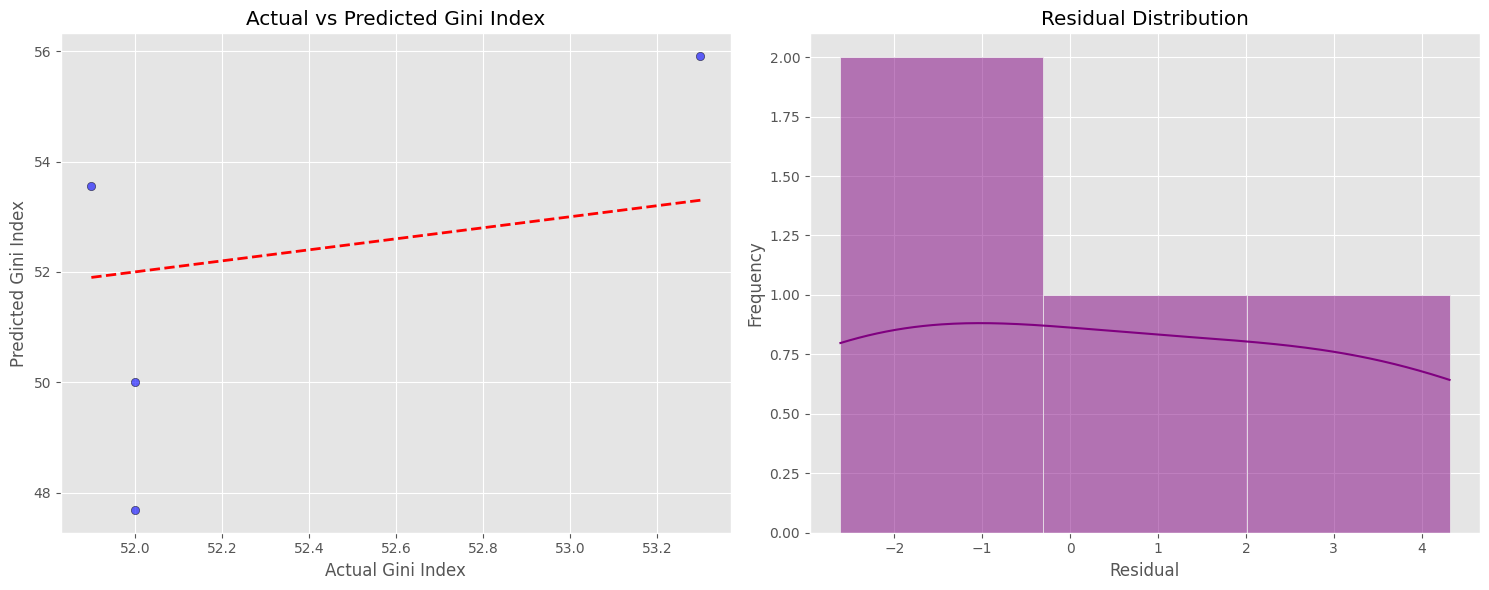

In [5]:
plt.figure(figsize=(15, 6))

# Actual vs Predicted Plot
plt.subplot(1, 2, 1)
plt.scatter(y_test, y_pred, color='blue', alpha=0.6, edgecolors='k')
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2)
plt.title('Actual vs Predicted Gini Index')
plt.xlabel('Actual Gini Index')
plt.ylabel('Predicted Gini Index')

# Residual Distribution Plot
plt.subplot(1, 2, 2)
residuals = y_test - y_pred
sns.histplot(residuals, kde=True, color='purple')
plt.title('Residual Distribution')
plt.xlabel('Residual')
plt.ylabel('Frequency')

plt.tight_layout()
plt.show()

## 5. Dedicated Interactive Prediction Interface
Use the sliders below to interactively predict the Gini Index for custom socio-economic scenarios. This is the **final delivery** of the modeling phase.

In [6]:
# DEDICATED INTERACTIVE INTERFACE
def predict_gini(education_spending, unemployment):
    # Prepare input
    custom_input = pd.DataFrame([[education_spending, unemployment]], 
                                columns=['Education_Spending_%GDP', 'Unemployment_%'])
    
    # Prediction using the trained model
    prediction = model.predict(custom_input)[0]
    
    print(f"--- Gini Index Prediction ---")
    print(f"Input Education Spending: {education_spending}%")
    print(f"Input Unemployment Rate: {unemployment}%")
    print(f"Predicted Gini Index: {prediction:.2f}")
    print(f"------------------------------")

# Create Interactive Sliders
interact(predict_gini, 
         education_spending=widgets.FloatSlider(min=0, max=15, step=0.1, value=4.5, description='Edu Spend %:'),
         unemployment=widgets.FloatSlider(min=0, max=30, step=0.1, value=7.0, description='Unemploy %:'));

interactive(children=(FloatSlider(value=4.5, description='Edu Spend %:', max=15.0), FloatSlider(value=7.0, des…

## 6. Conclusion and SDG 10 Alignment
**Phase 5: Documentation & Reporting (Final Delivery)**

The analysis shows how national indicators like education spending and unemployment relate to income inequality. Monitoring these relationships is crucial for achieving **SDG 10: Reduced Inequalities**. Developing predictive tools allows policymakers to simulate the impact of different economic scenarios on a nation's inequality profile.